In [1]:
import sys
sys.path.append('/blue/juannanzhou/lucaspereira/VEP/VEP_DNA-main-6_2')

In [2]:
import pandas as pd
import polars as pl
import seqpro as sp
import numpy as np
import pooch
from tqdm.auto import tqdm
from pathlib import Path
from tempfile import TemporaryDirectory
import genvarloader as gvl

/blue/juannanzhou/lucaspereira/Evo2/evo2_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.utils as utils
import src.clinvar as cv

In [4]:
# Set environment variable to suppress datetime warnings
import os
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning:jupyter_client.session'
import warnings
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")

In [5]:
# bgzip was being funky, fix for it
import os
from pathlib import Path

conda_bin = str(Path(sys.executable).parent)
os.environ["PATH"] = conda_bin + ":" + os.environ["PATH"]


# Changed cache path, hipergator home caches only have about 40 gigs of space

# GRCh38 chromosome 22 sequence
reference = pooch.retrieve(
    url="https://ftp.ensembl.org/pub/release-112/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.22.fa.gz",
    known_hash="sha256:974f97ac8ef7ffae971b63b47608feda327403be40c27e391ee4a1a78b800df5",
    progressbar=True,
    path = '/orange/juannanzhou/VEP_DNA_CACHE',
)
if not Path(f"{reference[:-3]}.bgz").exists():
    !gzip -dc {reference} | bgzip > {reference[:-3]}.bgz
reference = reference[:-3] + ".bgz"

# PLINK 2 files
variants = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pgen",
    known_hash="md5:31aba970e35f816701b2b99118dfc2aa",
    progressbar=True,
    fname="1kGP.chr22.pgen",
    path = '/orange/juannanzhou/VEP_DNA_CACHE',
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.psam",
    known_hash="md5:eefa7aad5acffe62bf41df0a4600129c",
    progressbar=True,
    fname="1kGP.chr22.psam",
    path = '/orange/juannanzhou/VEP_DNA_CACHE',
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pvar",
    known_hash="md5:5f922af91c1a2f6822e2f1bb4469d12b",
    progressbar=True,
    fname="1kGP.chr22.pvar",
    path = '/orange/juannanzhou/VEP_DNA_CACHE',
)

# BED
bed_path = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/chr22_egenes.bed",
    known_hash="md5:ccb55548e4ddd416d50dbe6638459421",
    progressbar=True,
    path = '/orange/juannanzhou/VEP_DNA_CACHE',
)

In [6]:
# In /data from repo, but I just wanted to centralize the vep data
bed = cv.read_bed("/orange/juannanzhou/VEP_DNA_CACHE/clinvar_utr_snv.bed.gz") 

print(bed.shape)
bed.head()

(13771, 24)


chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,CLNSIG_simple,CLNSIG_super_simple,GENE
str,i64,i64,str,f64,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,str,str,str
"""1""",1013541,1013542,"""chr1:1013541-1013542_T_C""",2.0,"""T""","""C""","""SO:0001623""","""5_prime_UTR_variant""",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""","""benign""","""benign""","""ISG15"""
"""1""",1055000,1055001,"""chr1:1055000-1055001_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""benign""","""benign""","""AGRN"""
"""1""",1055037,1055038,"""chr1:1055037-1055038_T_C""",2.0,"""T""","""C""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.38399,1282674,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055037T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""benign""","""benign""","""AGRN"""
"""1""",1055137,1055138,"""chr1:1055137-1055138_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.91793,1175253,"""MONDO:MONDO:0014052,MedGen:C38…","""Congenital_myasthenic_syndrome…","""NC_000001.11:g.1055137C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""benign""","""benign""","""AGRN"""
"""1""",1055153,1055154,"""chr1:1055153-1055154_G_A""",2.0,"""G""","""A""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.12181,1282812,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055153G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""","""benign""","""benign""","""AGRN"""


In [7]:
ds_path = TemporaryDirectory(suffix=".gvl").name

bed_chrom = bed.filter(pl.col('chrom')=='22')
gvl.write(
    path=ds_path,
    bed=gvl.with_length(bed_chrom, 8192),  # Maximum context length for evo2_7b_base model
    variants=variants,
    overwrite=True,
)

2025-06-04 17:13:15.691 | INFO     | genvarloader._dataset._write:write:75 - Writing dataset to /scratch/local/4398146/tmpifnopzc4.gvl
2025-06-04 17:13:15.702 | INFO     | genoray._pgen:_read_index:1078 - Loading genoray index.
2025-06-04 17:13:16.300 | INFO     | genvarloader._dataset._write:write:147 - Using 451 samples.
2025-06-04 17:13:16.302 | INFO     | genvarloader._dataset._write:write:153 - Writing genotypes.
Processing genotypes for 382 regions on contig 22:   8%|▊         | 30/382 [00:00<00:03, 93.81 region/s]2025-06-04 17:13:16.846 | WARNING  | genvarloader._dataset._write:_write_from_pgen:430 - A region has no variants for any sample. This could be expected depending on the region lengths and source of variants. However, this can also be caused by a mismatch between the reference genome used for the BED file coordinates and the one used for the variants.
Processing genotypes for 382 regions on contig 22: 100%|██████████| 382/382 [00:01<00:00, 243.15 region/s]
2025-06-04 17

In [8]:
ds = (
    gvl.Dataset.open(ds_path, reference=reference)
    .with_seqs("haplotypes")
    .with_len(8192)
)

2025-06-04 17:13:18.036 | INFO     | genvarloader._dataset._impl:open:191 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-06-04 17:13:18.060 | INFO     | genvarloader._dataset._reconstruct:from_path:183 - Loading variant data.
2025-06-04 17:13:18.088 | INFO     | genvarloader._dataset._impl:open:276 - Opened dataset:
GVL store at /scratch/local/4398146/tmpifnopzc4.gvl
Is subset: False
# of regions: 382
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None



In [9]:
ds_ref = (
    gvl.Dataset.open(ds_path, reference=reference)
    .with_seqs("reference") 
    .with_len(8192)
)

2025-06-04 17:13:18.096 | INFO     | genvarloader._dataset._impl:open:191 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-06-04 17:13:18.121 | INFO     | genvarloader._dataset._reconstruct:from_path:183 - Loading variant data.
2025-06-04 17:13:18.148 | INFO     | genvarloader._dataset._impl:open:276 - Opened dataset:
GVL store at /scratch/local/4398146/tmpifnopzc4.gvl
Is subset: False
# of regions: 382
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None



In [10]:
# Convert BED to sites
sites = cv.bed_to_sites(bed) 

sites_chrom = sites.filter(pl.col("CHROM").str.replace("chr","")=="22")

# Import sites_ds
site_ds = gvl.DatasetWithSites(ds, sites_chrom) 
site_ds_ref = gvl.DatasetWithSites(ds_ref, sites_chrom)

site_ds

In [11]:
site_ds.shape
site_ds_ref.dataset.reference

Reference(path=PosixPath('/orange/juannanzhou/VEP_DNA_CACHE/edfb24b9fee5f1060c26e092a696e447-Homo_sapiens.GRCh38.dna.chromosome.22.fa.bgz'), reference=array([78, 78, 78, ..., 78, 78, 78], shape=(50818468,), dtype=uint8), contigs=['22'], offsets=array([       0, 50818468]), pad_char=78)

In [12]:
# Add the site_name column
GVL.add_site_name(site_ds)

# Create path for results file, changed it for our needs
results_dir = os.path.join('/orange/juannanzhou/VEP_DNA_CACHE', 
                           "projects","data")
cohort = "1000_Genomes_on_GRCh38"
variant_set = "clinvar_utr_snv"
chrom = "chr22"
xr_ds_path = os.path.join(results_dir,
                         cohort,
                         variant_set,
                         f"{chrom}.zarr")
print(xr_ds_path)
os.makedirs(os.path.dirname(xr_ds_path), exist_ok=True)

# Initialize or load the dataset
all_models = ["evo2_7b_base"]
xr_ds = vp.init_or_load_xarray_dataset(
    xr_ds_path=xr_ds_path,
    all_models=all_models, 
    site_ds=site_ds, 
    force=True
)
xr_ds

/orange/juannanzhou/VEP_DNA_CACHE/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr
Initializing new Dataset at /orange/juannanzhou/VEP_DNA_CACHE/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr


Creating xarray Dataset with 1 model(s)
Saving xarray Dataset to /orange/juannanzhou/VEP_DNA_CACHE/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr


xarray Dataset saved to /orange/juannanzhou/VEP_DNA_CACHE/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr


/blue/juannanzhou/lucaspereira/Evo2/evo2_env/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/blue/juannanzhou/lucaspereira/Evo2/evo2_env/lib/python3.12/site-packages/zarr/core/array.py:4282: UserWarning: The dtype `<U27` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/blue/juannanzhou/lucaspereira/Evo2/evo2_env/lib/python3.12/site-packages/zarr/core/array.py:4282: UserWarning: The dtype `<U13` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/blue/juannanzhou/lucaspereira/Evo2/evo2_env/lib/python3.12

<xarray.Dataset> Size: 19MB
Dimensions:       (site: 382, sample: 452, ploid: 2, slot: 7)
Coordinates:
  * site          (site) <U27 41kB 'chr22:26483856-26483857_C_A' ... 'chr22:2...
  * sample        (sample) <U7 13kB 'REF' 'HG00096' ... 'NA20826' 'NA20828'
  * ploid         (ploid) <U1 8B '0' '1'
  * slot          (slot) <U13 364B 'VEP' 'time_total' ... 'len_seq_mut'
Data variables:
    evo2_7b_base  (site, sample, ploid, slot) float64 19MB nan nan ... nan nan

In [15]:
import warnings
warnings.filterwarnings("ignore", message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message=r"`torch.cuda.amp.autocast\(args\.\.\.\)` is deprecated")


xr_ds = vp.vep_pipeline(site_ds=site_ds, 
                           xr_ds_path=xr_ds_path,
                           run_models=["evo2_7b_base"],
                           all_models=["evo2_7b_base"], 
                           checkpoint_frequency="batch",
                           extra_samples=["REF"],
                           verbose=True,
                           force=False,
                           limit_samples=2,
                           limit_sites=1
                           )

2025-06-04 17:24:09.429 | INFO     | genvarloader._dataset._impl:open:191 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-06-04 17:24:09.460 | INFO     | genvarloader._dataset._reconstruct:from_path:183 - Loading variant data.
2025-06-04 17:24:09.487 | INFO     | genvarloader._dataset._impl:open:276 - Opened dataset:
GVL store at /scratch/local/4398146/tmpifnopzc4.gvl
Is subset: False
# of regions: 382
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None



Dataset will be saved to /orange/juannanzhou/VEP_DNA_CACHE/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr
Loading existing results from /orange/juannanzhou/VEP_DNA_CACHE/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr
xarray Dataset dimensions: FrozenMappingWarningOnValuesAccess({'ploid': 2, 'site': 382, 'sample': 452, 'slot': 7})
Using reference genome from /orange/juannanzhou/VEP_DNA_CACHE/edfb24b9fee5f1060c26e092a696e447-Homo_sapiens.GRCh38.dna.chromosome.22.fa.bgz


Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 2278.89it/s]


Found complete file in repo: evo2_7b_base.pt



100%|██████████| 32/32 [00:00<00:00, 383.58it/s]


...

30
30
mut_res.shape: (30,)
wt_res.shape: (30,)





  0%|          | 0/30 [00:00<?, ?it/s]/blue/juannanzhou/lucaspereira/Evo2/evo2/vortex/vortex/model/tokenizer.py:161: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  return list(np.fromstring(text, dtype=np.uint8))



  3%|▎         | 1/30 [00:00<00:21,  1.32it/s]


  7%|▋         | 2/30 [00:01<00:20,  1.34it/s]


 10%|█         | 3/30 [00:02<00:20,  1.34it/s]


 13%|█▎        | 4/30 [00:02<00:19,  1.34it/s]


 17%|█▋        | 5/30 [00:03<00:18,  1.33it/s]


 20%|██        | 6/30 [00:04<00:17,  1.34it/s]


 23%|██▎       | 7/30 [00:05<00:17,  1.34it/s]


 27%|██▋       | 8/30 [00:05<00:16,  1.34it/s]


 30%|███       | 9/30 [00:06<00:15,  1.34it/s]


 33%|███▎      | 10/30 [00:07<00:14,  1.34it/s]


 37%|███▋      | 11/30 [00:08<00:14,  1.34it/s]


 40%|████      | 12/30 [00:08<00:13,  1.34it/s]


 43%|████▎     | 13/30 [00:09<00:12,  1.34it/s]


 47%|████▋     | 14/30 [00:10<00:11,  1.34it/s]


 

30
30
mut_res.shape: (30,)
wt_res.shape: (30,)





  0%|          | 0/4 [00:00<?, ?it/s]/blue/juannanzhou/lucaspereira/Evo2/evo2/vortex/vortex/model/tokenizer.py:161: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  return list(np.fromstring(text, dtype=np.uint8))



 25%|██▌       | 1/4 [00:00<00:02,  1.33it/s]


 50%|█████     | 2/4 [00:01<00:01,  1.33it/s]


 75%|███████▌  | 3/4 [00:02<00:00,  1.33it/s]


100%|██████████| 4/4 [00:03<00:00,  1.33it/s]



  0%|          | 0/4 [00:00<?, ?it/s]


 25%|██▌       | 1/4 [00:00<00:02,  1.35it/s]


 50%|█████     | 2/4 [00:01<00:01,  1.34it/s]


 75%|███████▌  | 3/4 [00:02<00:00,  1.34it/s]


100%|██████████| 4/4 [00:02<00:00,  1.33it/s]


Iterating over sample batches (452 samples total): 100%|██████████| 31/31 [16:38<00:00, 33.37s/it]

                                                                                                  
Iterating over sites:   1%|          | 2/382 [16:38<52:40:51, 499.08s

4
4
mut_res.shape: (4,)
wt_res.shape: (4,)


In [16]:
vep_df = vp.load_vep_results(xr_ds, dropna_subset=['evo2_7b_base'])

Contents of xarray after filtering [filled values / total values]:
 - rows: 5424
 - sites: 1 / 382
 - samples: 452 / 452
 - ploid: 2 / 2
 - slots: 6 / 7


NameError: name 'vep_df' is not defined

In [17]:
xr_ds

<xarray.Dataset> Size: 19MB
Dimensions:       (ploid: 2, site: 382, sample: 452, slot: 7)
Coordinates:
  * ploid         (ploid) object 16B '0' '1'
  * site          (site) object 3kB 'chr22:26483856-26483857_C_A' ... 'chr22:...
  * sample        (sample) object 4kB 'REF' 'HG00096' ... 'NA20826' 'NA20828'
  * slot          (slot) object 56B 'VEP' 'time_total' ... 'len_seq_mut'
Data variables:
    evo2_7b_base  (site, sample, ploid, slot) float64 19MB nan nan ... nan nan

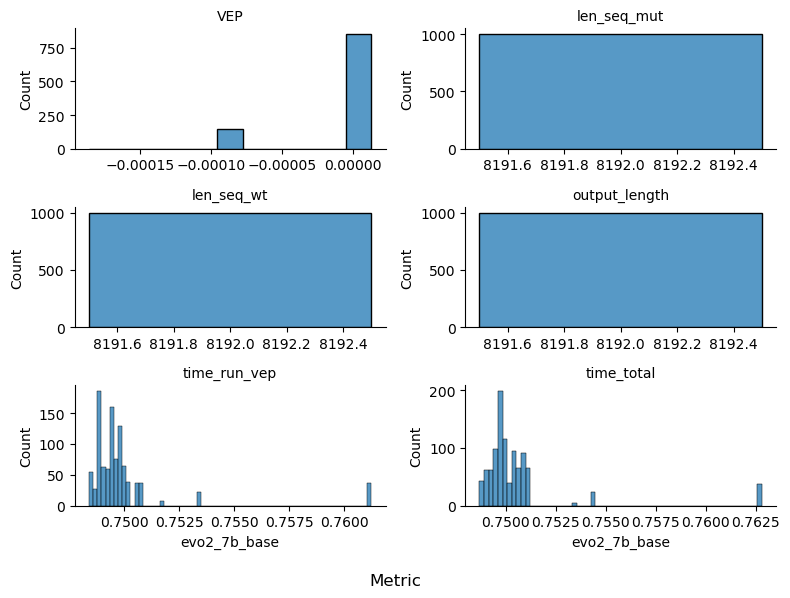

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with subplots for each slot
g = sns.FacetGrid(vep_df.groupby("slot").sample(1000, replace=True).sort_values("slot"),
                  col="slot",  # Changed from row to col
                  col_wrap=2,  # Added col_wrap to wrap facets
                  height=2, 
                  aspect=2, 
                  margin_titles=True,
                  sharex=False, 
                  sharey=False)
g.map_dataframe(sns.histplot, x="evo2_7b_base")
g.set_titles("{col_name}")
g.fig.supxlabel("Metric")
plt.tight_layout()

In [ ]:
print(gvl.__version__)

import genvarloader as gvl
print(f"GVL package location: {gvl.__file__}")
print(f"GVL package parent dir: {os.path.dirname(gvl.__file__)}")

!{sys.executable} -m pip show genvarloader

In [ ]:
annhaps, flags = site_ds[1, 4]
masked_arr = annhaps.var_idxs
ref_arr = annhaps.ref_coords

print(masked_arr[1])
#print(ref_arr[1])

var_inds = np.where(masked_arr[1] == -2)
print(var_inds)
print(masked_arr[1][var_inds])
